# NHANES evaluation

This notebook extracts Sensori day embeddings for the public NHANES cohort, prepares the matching tabular variables, visualizes the embedding space, and compares three participant-level linear probes across the NHANES outcomes.

Install the package first with `pip install -e .` from the repository root.

In [1]:
import json
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from umap import UMAP

from scripts.tutorial_nhanes.prepare_nhanes_tabular import prepare_tabular
from sensori.inference import extract_embeddings

## Extract Sensori embeddings

Run the [preprocessing notebook](nhanes_preprocessing.ipynb) first to create the 10 Hz, 24-hour arrays, then point `PROCESSED_DATA_DIR` at its output directory. Extraction uses a GPU when available and reuses an existing embedding file.

In [2]:
# Change this to the directory containing your preprocessed NHANES arrays.
PROCESSED_DATA_DIR = Path('/path/to/processed_nhanes_days')
EMBEDDING_PATH = Path('nhanes_embeddings.npy')

# BATCH_SIZE = 100 needs about 70 GB of GPU memory for full-day inputs; reduce it if you run out.
BATCH_SIZE = 100
NUM_WORKERS = 6
SEED = 111

extract_embeddings(
    PROCESSED_DATA_DIR,
    output_path=EMBEDDING_PATH,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

## Prepare the NHANES tabular data

The source XPT tables are downloaded to `scripts/tutorial_nhanes/tabular_files/` and reused on later runs. Only participants with public physical-activity-monitor data are kept.

In [3]:
tabular = prepare_tabular()
tabular.head()

,eid,cycle,firmware,age,Sex,BMI,Current tobacco smoking,Alcohol drinker status,Regular alcohol drinking,Overall health rating,...,difficulty_eat_utensils,difficulty_dress_self,difficulty_stand_long,difficulty_sit_long,difficulty_reach_overhead,difficulty_grasp_small_objects,difficulty_go_out_events,difficulty_attend_social,difficulty_leisure_home,difficulty_push_pull_large
0,62161,2011-2012,1.8.0,22.0,Male,23.3,No,Never,No,Good,...,No difficulty,Some difficulty,No difficulty,No difficulty,No difficulty,No difficulty,Do not do this activity,Do not do this activity,No difficulty,Do not do this activity
1,62163,2011-2012,2.4.0,14.0,Male,17.3,<NA>,<NA>,<NA>,Good,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62164,2011-2012,2.4.0,44.0,Female,23.2,No,<NA>,<NA>,NaN,...,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty,No difficulty
3,62165,2011-2012,1.9.0,14.0,Female,27.2,<NA>,<NA>,<NA>,Fair,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62166,2011-2012,1.9.0,9.0,Male,16.2,<NA>,<NA>,<NA>,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Build participant-level embeddings

Each valid day embedding is L2-normalized before a participant's days are averaged. The inner join defines the analysis cohort: participants with both tabular data and at least one valid embedding.

In [4]:
def load_participant_embeddings(path):
    day_embeddings = np.load(path, allow_pickle=True).item()
    participants = {}
    for eid, days in day_embeddings.items():
        days = np.asarray(days, dtype=np.float32)
        norms = np.linalg.norm(days, axis=1)
        valid = np.isfinite(norms) & (norms > 0)  # a non-finite day gives a non-finite norm
        if valid.any():
            participants[str(eid)] = (days[valid] / norms[valid, None]).mean(axis=0)

    frame = pd.DataFrame.from_dict(participants, orient='index')
    frame.index.name = 'eid'
    frame.columns = [f'embedding_{column:03d}' for column in range(frame.shape[1])]
    return frame


embeddings = load_participant_embeddings(EMBEDDING_PATH)
embedding_columns = embeddings.columns.tolist()
tabular['eid'] = tabular['eid'].astype(str)
cohort = tabular.set_index('eid').join(embeddings, how='inner')
print(f'Participants with tabular data and embeddings: {len(cohort):,}')
cohort.reset_index()[['eid', 'cycle', 'age', 'Sex', 'BMI']].head()

Participants with tabular data and embeddings: 12,236


,eid,cycle,age,Sex,BMI
0,62161,2011-2012,22.0,Male,23.3
1,62163,2011-2012,14.0,Male,17.3
2,62164,2011-2012,44.0,Female,23.2
3,62165,2011-2012,14.0,Female,27.2
4,62166,2011-2012,9.0,Male,16.2


## UMAP visualization

UMAP coordinates come from the Sensori embeddings alone; age, sex, BMI and firmware only annotate the points. `prepare_tabular` parses firmware from the official [2011–2012](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/PAX80_G.htm) and [2013–2014](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/PAX80_H.htm) raw-data filenames, and both cycles used the same ActiGraph GT3X+ model.

Within each cluster the map is ordered by characteristics the model never saw: age runs from young at the top to old at the bottom, sex separates along UMAP 1, and higher BMI concentrates lower down.

The two clusters themselves are the firmware version: 2.2.0 or earlier in one, 2.3.0 or later in the other. This is not a survey-cycle effect: in the table below the 2011–2012 cycle contributes 3,236 participants to the first cluster and 3,017 to the second. ActiGraph's idle sleep mode changed across this firmware range — when the monitor detects no motion it stops sampling, and the values written while it sleeps are not the same before and after the change. Sleep and non-wear therefore have a systematically different waveform in the two groups, and Sensori separates them accordingly. A device artefact is the largest single source of variation in this embedding space, which is worth remembering in any analysis that mixes firmware versions.

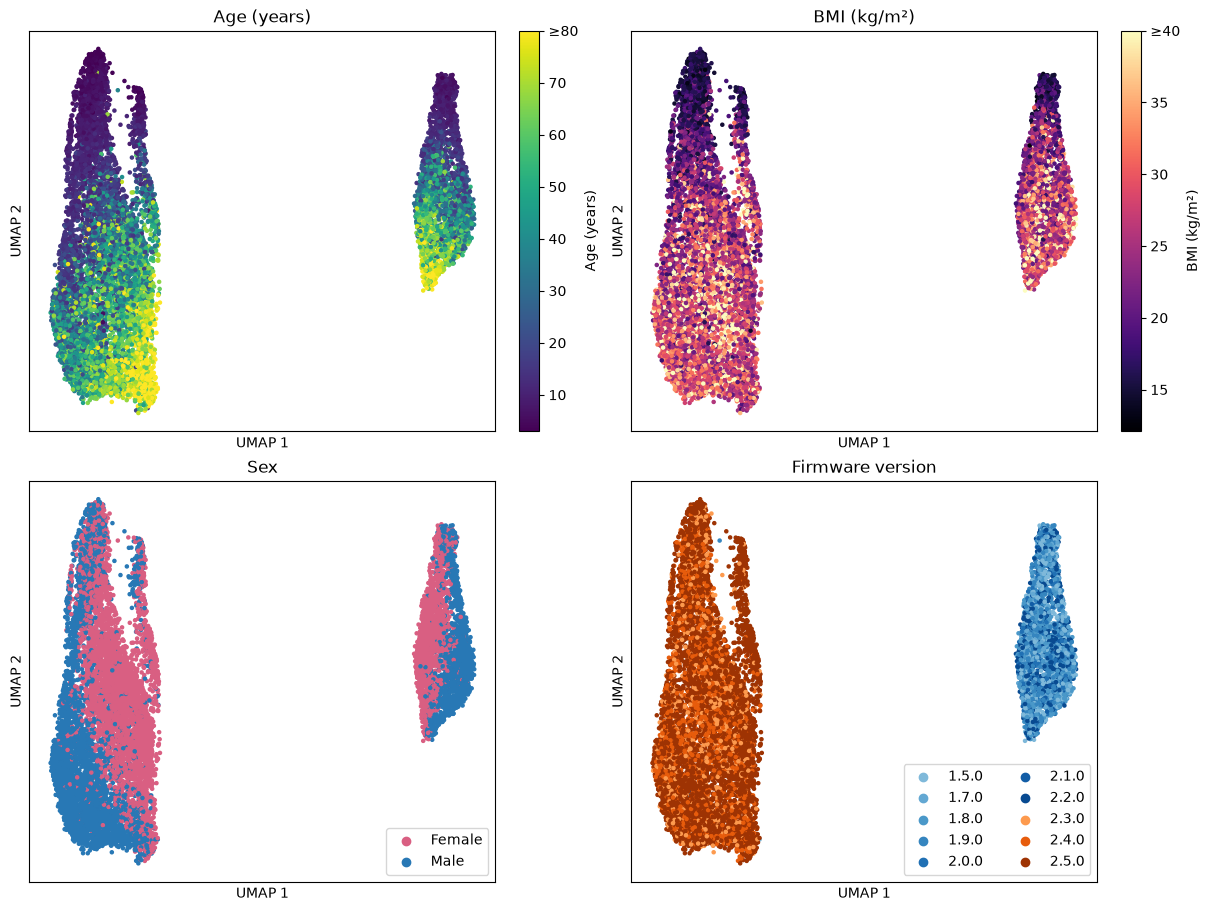

cycle,2011-2012,2013-2014,Total
Firmware,,,
1.5.0,602,0,602
1.7.0,359,0,359
1.8.0,566,0,566
1.9.0,767,0,767
2.0.0,288,0,288
2.1.0,62,1,63
2.2.0,592,51,643
2.3.0,534,557,1091
2.4.0,1756,100,1856


In [5]:
umap_table = cohort.copy()
umap_table[['UMAP1', 'UMAP2']] = UMAP(n_neighbors=50, random_state=SEED, n_jobs=1).fit_transform(
    umap_table[embedding_columns]
)


def version_key(value):
    return tuple(map(int, value.split('.')))


firmware_versions = sorted(umap_table['firmware'].unique(), key=version_key)
early = [version for version in firmware_versions if version_key(version) < (2, 3)]
late = [version for version in firmware_versions if version_key(version) >= (2, 3)]
firmware_colors = {
    **dict(zip(early, plt.get_cmap('Blues')(np.linspace(0.45, 0.9, len(early))))),
    **dict(zip(late, plt.get_cmap('Oranges')(np.linspace(0.45, 0.9, len(late))))),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()
for axis, column, title, cmap, upper in (
    (axes[0], 'age', 'Age (years)', 'viridis', 80),
    (axes[1], 'BMI', 'BMI (kg/m²)', 'magma', 40),
):
    table = umap_table.dropna(subset=[column])
    values = table[column].clip(upper=upper)
    points = axis.scatter(table['UMAP1'], table['UMAP2'], c=values, s=5, cmap=cmap)
    colorbar = fig.colorbar(points, ax=axis, label=title)
    ticks = [tick for tick in colorbar.get_ticks() if values.min() <= tick < upper]
    colorbar.set_ticks([*ticks, upper], labels=[*(f'{tick:g}' for tick in ticks), f'≥{upper}'])
    axis.set_title(title)

for axis, column, title, colors in (
    (axes[2], 'Sex', 'Sex', {'Female': '#D95F82', 'Male': '#2878B5'}),
    (axes[3], 'firmware', 'Firmware version', firmware_colors),
):
    table = umap_table.dropna(subset=[column]).sample(frac=1, random_state=SEED)
    axis.scatter(table['UMAP1'], table['UMAP2'], c=table[column].map(colors), s=5)
    for value, color in colors.items():
        axis.scatter([], [], color=color, label=value)
    axis.set_title(title)
    axis.legend(ncol=2 if column == 'firmware' else 1)

for axis in axes:
    axis.set(xticks=[], yticks=[], xlabel='UMAP 1', ylabel='UMAP 2')
plt.show()

firmware_distribution = pd.crosstab(
    umap_table['firmware'], umap_table['cycle'], margins=True, margins_name='Total'
).reindex([*firmware_versions, 'Total'])
firmware_distribution.index.name = 'Firmware'
firmware_distribution

## Encode the evaluation targets

Here we repeat our study’s NHANES analysis: 3 harmonized health outcomes (regular alcohol drinking, current tobacco smoking and overall health rating) and 19 physical-function items.

Participants are restricted to `AGE_RANGE`, the half-open interval 43 ≤ age < 80. That bracket is the UK Biobank accelerometry cohort’s own age span, so applying it to NHANES keeps the two cohorts comparable.

The table below reports each target's positive ratio and number of available participants.

In [6]:
def load_evaluation_json(filename):
    with files('scripts.tutorial_nhanes').joinpath(filename).open(encoding='utf-8') as handle:
        return json.load(handle)


items = load_evaluation_json('covariate_items.json')
mappings = load_evaluation_json('covariate_mappings.json')
TARGETS = [*items['common_items'], *items['nhanes_physical_function']]
AGE_RANGE = (43, 80)


def encode_column(data, column):
    mapping = mappings['categorical_mappings'][column]
    if '$ref' in mapping:
        mapping = mappings['shared_mappings'][mapping['$ref']]
    unexpected = set(data[column].dropna().unique()) - set(mapping)
    if unexpected:
        raise ValueError(f'Unmapped values for {column}: {sorted(unexpected, key=str)}')
    return pd.to_numeric(data[column].map(mapping), errors='coerce')


model_data = cohort[cohort['age'].between(*AGE_RANGE, inclusive='left')].copy()
print(f'Participants aged {AGE_RANGE[0]} to {AGE_RANGE[1] - 1}: {len(model_data):,}')

model_data['Sex'] = encode_column(model_data, 'Sex')
for target in TARGETS:
    model_data[target] = encode_column(model_data, target)

target_summary = pd.DataFrame(
    {'participants': model_data[TARGETS].notna().sum(), 'positive_ratio': model_data[TARGETS].mean()}
)
target_summary.round(3)

Participants aged 43 to 79: 4,605


,participants,positive_ratio
Regular alcohol drinking,4323,0.428
Current tobacco smoking,4601,0.195
Overall health rating,4349,0.713
difficulty_walk_quarter_mile,4577,0.247
difficulty_walk_ten_steps,4585,0.219
difficulty_stoop_crouch_kneel,4559,0.317
difficulty_lift_carry,4549,0.178
difficulty_house_chores,4513,0.164
difficulty_prepare_meals,4477,0.069
difficulty_walk_between_rooms,4600,0.074


## Linear probes

Five-fold cross-validation of three feature sets: age–sex–BMI, the Sensori embedding, and both together.

No inner hyperparameter search is run: `C=1` for age–sex–BMI and `C=0.001` wherever embeddings are used. Cross-validated performance is close to flat along the regularization path, so these fixed values are not a tuned choice. This is a within-NHANES predictive benchmark; the manuscript instead evaluated the three harmonized health outcomes with probes fitted in UKB.

In [7]:
N_SPLITS = 5


def evaluate_target(data, target, feature_set, columns, C):
    target_data = data.loc[data[target].notna()]
    features = target_data[columns]
    labels = target_data[target].astype(int)
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    rows = []
    for fold, (train_index, test_index) in enumerate(folds.split(features, labels), start=1):
        model = make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            LogisticRegression(C=C, max_iter=10_000, class_weight='balanced'),
        )
        model.fit(features.iloc[train_index], labels.iloc[train_index])
        scores = model.predict_proba(features.iloc[test_index])[:, 1]
        rows.append(
            {
                'target': target,
                'feature_set': feature_set,
                'fold': fold,
                'n_test': len(test_index),
                'C': C,
                'AUROC': roc_auc_score(labels.iloc[test_index], scores),
            }
        )
    return pd.DataFrame(rows)

In [8]:
FEATURE_SETS = {
    'Age + sex + BMI': (['age', 'Sex', 'BMI'], 1.0),
    'Sensori embedding': (embedding_columns, 0.001),
    'Age + sex + BMI + Sensori embedding': (['age', 'Sex', 'BMI', *embedding_columns], 0.001),
}

fold_results = pd.concat(
    [
        evaluate_target(model_data, target, feature_set, columns, C)
        for feature_set, (columns, C) in FEATURE_SETS.items()
        for target in tqdm(TARGETS, desc=feature_set)
    ],
    ignore_index=True,
)

## Summary

The table reports the mean and standard deviation across the five folds.

In [9]:
summary = (
    fold_results.groupby(['target', 'feature_set'], sort=False)
    .agg(
        n_participants=('n_test', 'sum'),
        AUROC_mean=('AUROC', 'mean'),
        AUROC_std=('AUROC', 'std'),
        C=('C', 'first'),
    )
    .reset_index()
    .round(6)
)

summary

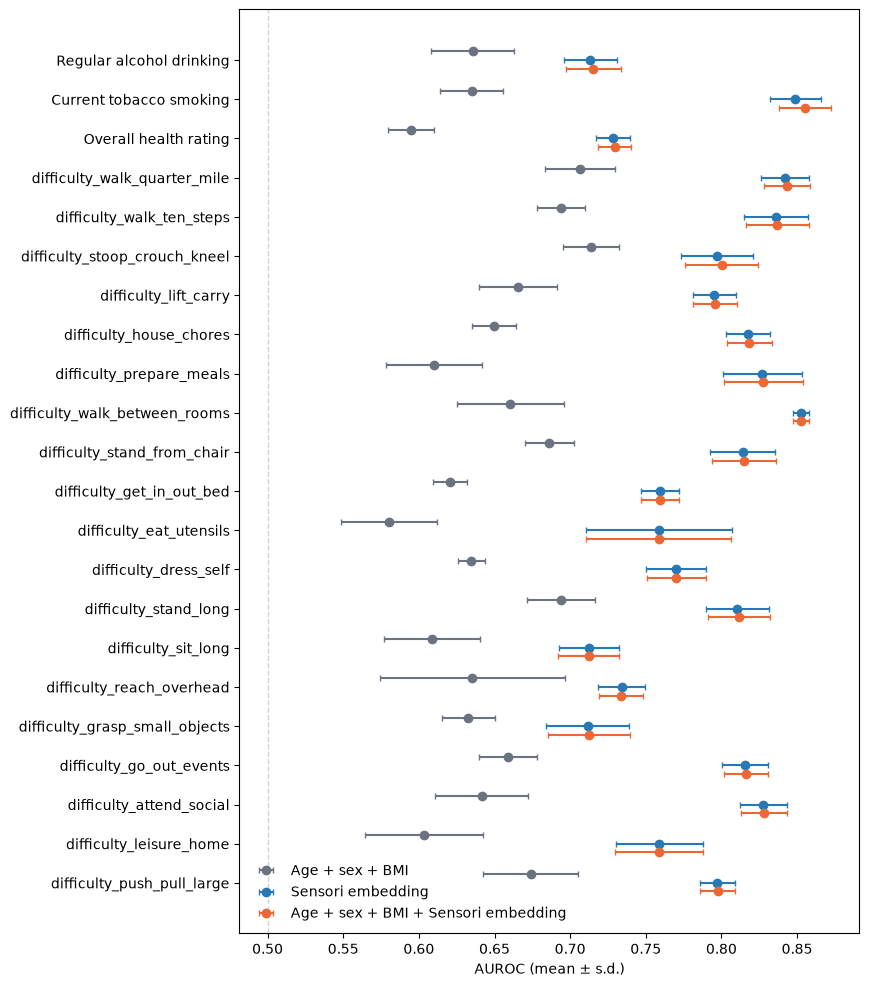

In [10]:
COLORS = ('#6B7280', '#2878B5', '#EB6834')
indexed_summary = summary.set_index(['target', 'feature_set'])

fig, axis = plt.subplots(figsize=(8, 12))
positions = np.arange(len(TARGETS))
for offset, feature_set, color in zip((-0.22, 0.0, 0.22), FEATURE_SETS, COLORS):
    values = indexed_summary.loc[[(target, feature_set) for target in TARGETS]]
    axis.errorbar(
        values['AUROC_mean'],
        positions + offset,
        xerr=values['AUROC_std'],
        fmt='o',
        color=color,
        capsize=2,
        label=feature_set,
    )
axis.axvline(0.5, color='lightgray', linestyle='--', linewidth=1)
axis.set(yticks=positions, yticklabels=TARGETS, xlabel='AUROC (mean ± s.d.)')
axis.invert_yaxis()
axis.legend(frameon=False)
plt.show()